In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('q3_retail_promotions.csv')

def engineer_features(df):
    df['transaction_date'] = pd.to_datetime(df['transaction_date'])
    df['year'] = df['transaction_date'].dt.year
    df['month'] = df['transaction_date'].dt.month
    df['day_of_week'] = df['transaction_date'].dt.dayofweek
    df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)
    return df

df = engineer_features(df)
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

     transaction_date  year  month  day_of_week  is_month_end
794        2024-01-31  2024      1            2             1
82         2022-02-28  2022      2            0             1
1060       2024-09-04  2024      9            2             0
1173       2024-12-06  2024     12            4             0
1092       2024-09-30  2024      9            0             1


In [3]:
df = df.sort_values('transaction_date')

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

In retail forecasting, the goal is to predict the future based on the past. Using a random split would allow the model to peek into future trends (e.g., seeing Christmas sales patterns from the middle of the dataset) to predict past events. This creates Data Leakage, leading to overly optimistic performance metrics that will fail in a real-world production environment where the future is unknown.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density', 'store_id']

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_features), ('num', StandardScaler(), num_features)])

--- Linear Regression ---
RMSE: 27.12
MAE: 21.05



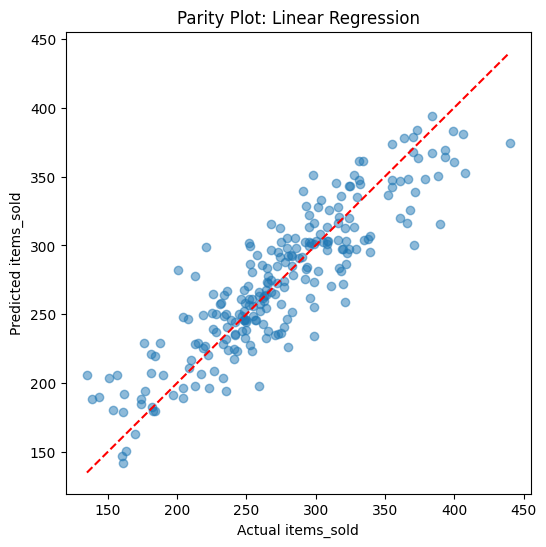

--- Random Forest ---
RMSE: 30.56
MAE: 23.95



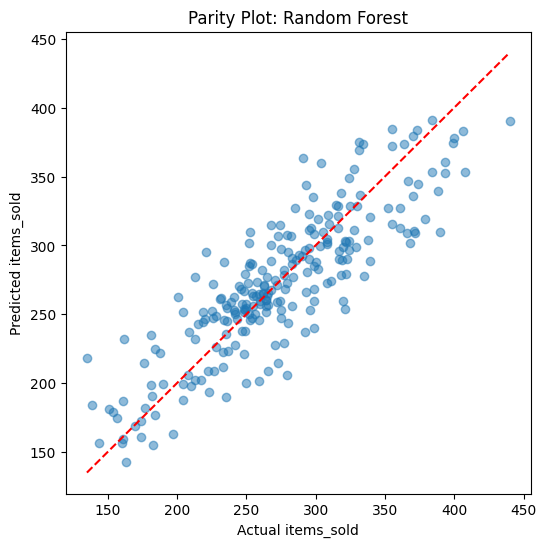

Top 5 Most Influential Features (RF):
is_festival            0.173454
store_size_small       0.167183
location_type_urban    0.108432
day_of_week            0.087752
is_weekend             0.059848
dtype: float64


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

models = {"Linear Regression": LinearRegression(), "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)}

results = {}

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results[name] = clf 
    
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}\n")
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual items_sold')
    plt.ylabel('Predicted items_sold')
    plt.title(f'Parity Plot: {name}')
    plt.show()

rf_model = results["Random Forest"]
ohe_cols = rf_model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(cat_features)
all_cols = np.concatenate([ohe_cols, num_features])

importances = rf_model.named_steps['regressor'].feature_importances_
feat_importances = pd.Series(importances, index=all_cols).sort_values(ascending=False)

print("Top 5 Most Influential Features (RF):")
print(feat_importances.head(5))